In [3]:
#samp rate is given (128hz)
import os
import scipy.io
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal import butter, filtfilt
from scipy.integrate import simpson


from sklearn.decomposition import FastICA

folder_path = r"C:\Users\ANJALI\Downloads\archive (5)\EEG Data\EEG Data"

all_data = {}

for file in os.listdir(folder_path):

    if file.endswith(".mat"):|
        

        file_path = os.path.join(folder_path, file)

        data = scipy.io.loadmat(file_path)

        all_data[file] = data

        print("Loaded:", file)

print("Total files:", len(all_data))

Loaded: eeg_record1.mat
Loaded: eeg_record10.mat
Loaded: eeg_record11.mat
Loaded: eeg_record12.mat
Loaded: eeg_record13.mat
Loaded: eeg_record14.mat
Loaded: eeg_record15.mat
Loaded: eeg_record16.mat
Loaded: eeg_record17.mat
Loaded: eeg_record18.mat
Loaded: eeg_record19.mat
Loaded: eeg_record2.mat
Loaded: eeg_record20.mat
Loaded: eeg_record21.mat
Loaded: eeg_record22.mat
Loaded: eeg_record23.mat
Loaded: eeg_record24.mat
Loaded: eeg_record25.mat
Loaded: eeg_record26.mat
Loaded: eeg_record27.mat
Loaded: eeg_record28.mat
Loaded: eeg_record29.mat
Loaded: eeg_record3.mat
Loaded: eeg_record30.mat
Loaded: eeg_record31.mat
Loaded: eeg_record32.mat
Loaded: eeg_record33.mat
Loaded: eeg_record34.mat
Loaded: eeg_record4.mat
Loaded: eeg_record5.mat
Loaded: eeg_record6.mat
Loaded: eeg_record7.mat
Loaded: eeg_record8.mat
Loaded: eeg_record9.mat
Total files: 34


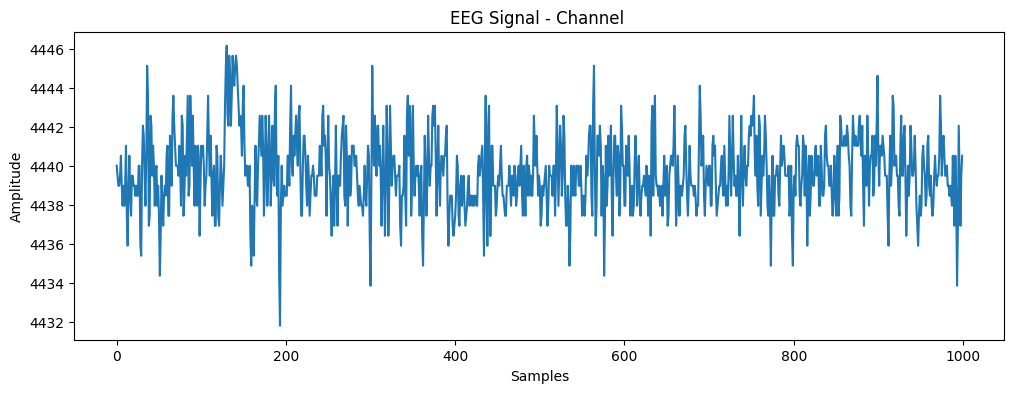

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(eeg[:1000,3])
plt.title("EEG Signal - Channel ")
plt.xlabel("Samples") 
plt.ylabel("Amplitude")
plt.show()
# This shows raw brain signal waveform.

In [9]:
print(all_data["eeg_record1.mat"].keys())

eeg = all_data["eeg_record1.mat"]["o"]["data"]

print(eeg)

eeg = all_data["eeg_record1.mat"]["o"][0][0]["data"]

print(eeg.shape)

print("Number of channels:", eeg.shape[1])

print("Number of samples:", eeg.shape[0])

sampling_rate = 128

duration = eeg.shape[0] / sampling_rate

print("Recording duration (seconds):", duration)
print("Recording duration (minutes):", duration/60)

print("Missing values:", np.isnan(eeg).sum())
eeg_channels = eeg[:, 2:16]

print("EEG shape:", eeg_channels.shape)

channel_names = [
"AF3","F7","F3","FC5","T7","P7","O1",
"O2","P8","T8","FC6","F4","F8","AF4"
]

print(channel_names)

std = np.std(eeg_channels, axis=0)

print("Standard deviation:", std)
eeg_channels = eeg[:, 2:16]

print("EEG shape:", eeg_channels.shape)

eeg_clean = np.delete(eeg_channels, [12,13], axis=1)

print("Clean EEG shape:", eeg_clean.shape)

# compute average across channels for each time sample
avg_ref = np.mean(eeg_clean, axis=1, keepdims=True)

# subtract average reference
eeg_ref = eeg_clean - avg_ref

print("Referenced EEG shape:", eeg_ref.shape)



dict_keys(['__header__', '__version__', '__globals__', 'o'])
[[array([[  3.,   0., 463., ...,   0.,   0.,   0.],
         [  4.,   0.,   0., ...,   0.,   0.,   0.],
         [  5.,   0., 447., ...,   0.,   0.,   0.],
         ...,
         [ 25.,   0.,   0., ...,   0.,   0.,   0.],
         [ 26.,   0.,   0., ...,   0.,   0.,   0.],
         [ 27.,   0.,   0., ...,   0.,   0.,   0.]], shape=(308868, 25))]]
(308868, 25)
Number of channels: 25
Number of samples: 308868
Recording duration (seconds): 2413.03125
Recording duration (minutes): 40.2171875
Missing values: 0
EEG shape: (308868, 14)
['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
Standard deviation: [190.95069345   9.71686923 181.76152696 183.19922814   9.35575613
  12.08033966 171.82578381 206.83215633 197.71911394 167.86638309
   8.78028903  12.04667628   3.32405248   5.86689472]
EEG shape: (308868, 14)
Clean EEG shape: (308868, 12)
Referenced EEG shape: (308868, 12)


Filtered EEG shape: (308868, 12)


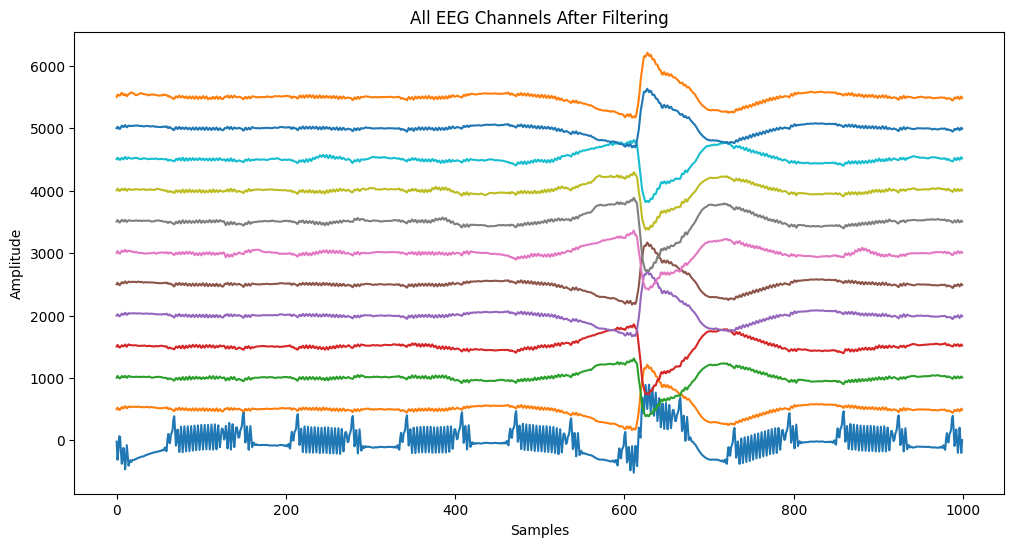

In [11]:
fs = 128  

# Filter range
lowcut = 0.5
highcut = 40

# Create Butterworth bandpass filter
b, a = butter(4, [lowcut/(fs/2), highcut/(fs/2)], btype='band')

# Apply filter to EEG data
eeg_filtered = filtfilt(b, a, eeg_ref, axis=0)
eeg_filtered = eeg_filtered.astype(float)
print("Filtered EEG shape:", eeg_filtered.shape)
plt.figure(figsize=(12,6))

for i in range(12):
    plt.plot(eeg_filtered[:1000,i] + i*500)

plt.title("All EEG Channels After Filtering")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


ICA components shape: (308868, 12)


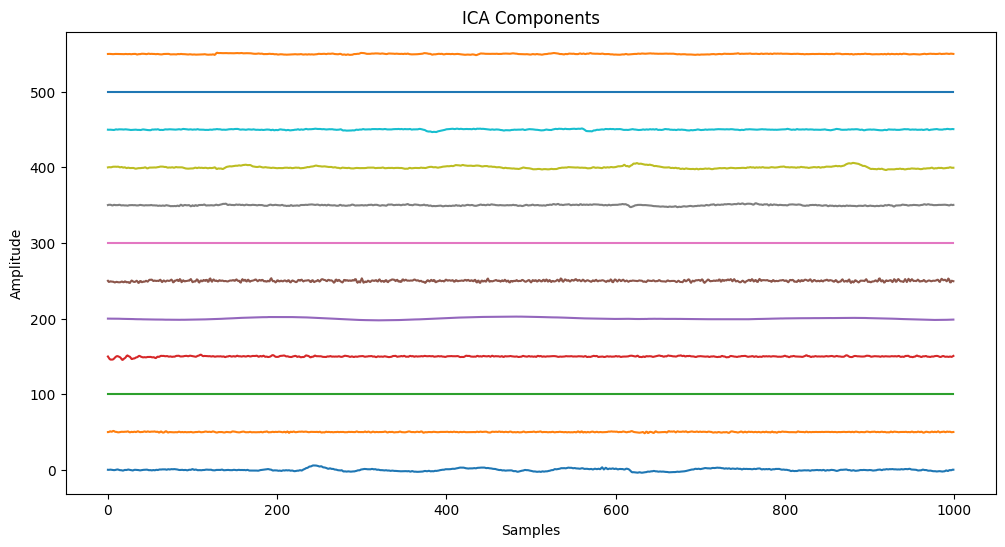

In [38]:
# Transpose because ICA expects (samples, features)
ica = FastICA(n_components=12, random_state=0)

components = ica.fit_transform(eeg_filtered)

print("ICA components shape:", components.shape)


artifact_components = [2,6,10]

components[:, artifact_components] = 0


eeg_ica_clean = ica.inverse_transform(components)
# ICA PLOT
plt.figure(figsize=(12,6))

for i in range(12):
    plt.plot(components[:1000,i] + i*50)

plt.title("ICA Components")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [15]:
print("ICA components shape:", components.shape)
plt.figure(figsize=(12,8))

ICA components shape: (308868, 12)


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

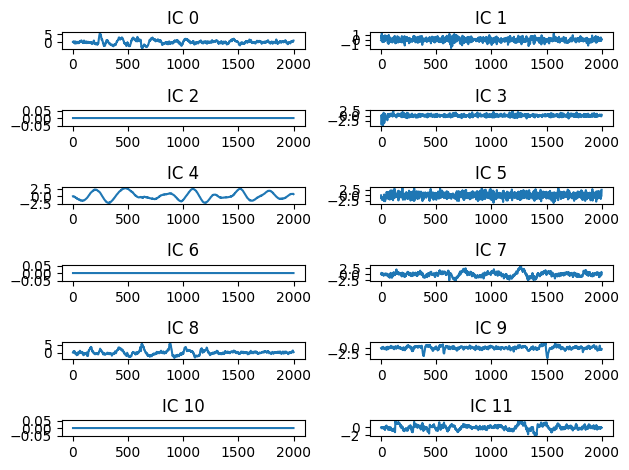

In [16]:
for i in range(12):
    plt.subplot(6,2,i+1)
    plt.plot(components[:2000,i])
    plt.title("IC "+str(i))

plt.tight_layout()
plt.show()

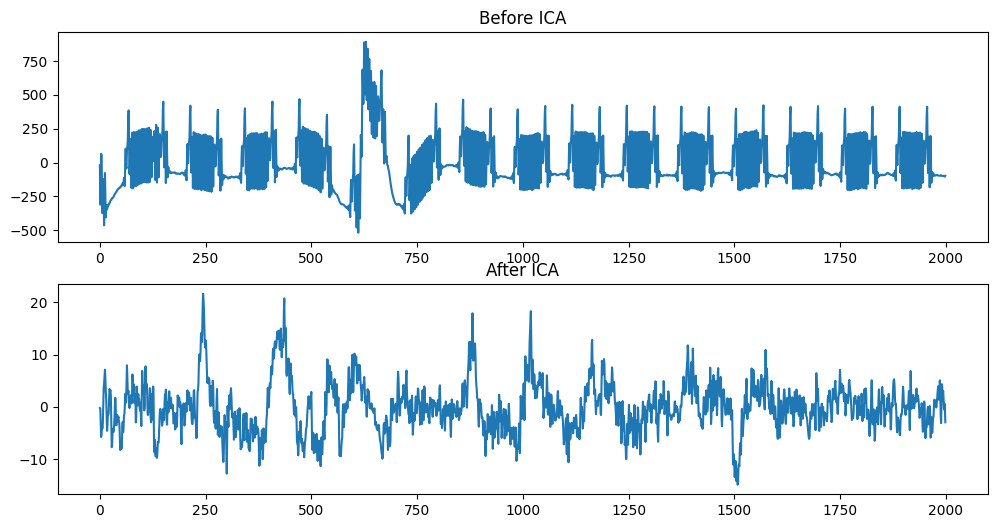

In [17]:
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(eeg_filtered[:2000,0])
plt.title("Before ICA")

plt.subplot(2,1,2)
plt.plot(eeg_ica_clean[:2000,0])
plt.title("After ICA")

plt.show()

Epochs shape: (1206, 256, 12)
(1206, 256, 12)
Epochs shape: (1206, 256, 12)


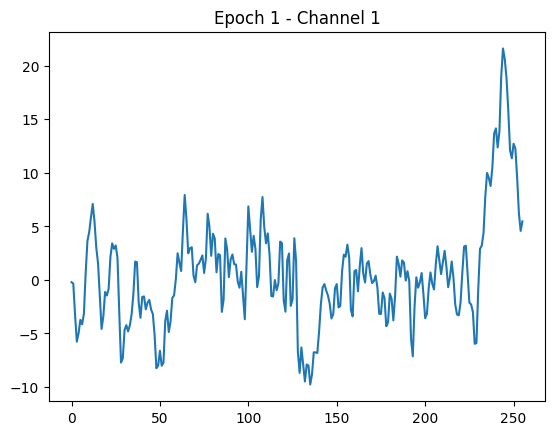

In [18]:
fs = 128                # sampling frequency
epoch_length = 2 * fs   # 2 second epoch = 256 samples

data = eeg_ica_clean

num_samples = data.shape[0]
num_channels = data.shape[1]

num_epochs = num_samples // epoch_length

epochs = data[:num_epochs * epoch_length].reshape(num_epochs, epoch_length, num_channels)

print("Epochs shape:", epochs.shape)
print(epochs.shape)

print("Epochs shape:", epochs.shape)
plt.plot(epochs[0,:,0])
plt.title("Epoch 1 - Channel 1")
plt.show()

Epochs shape: (1206, 256, 12)
(1206, 256, 12)


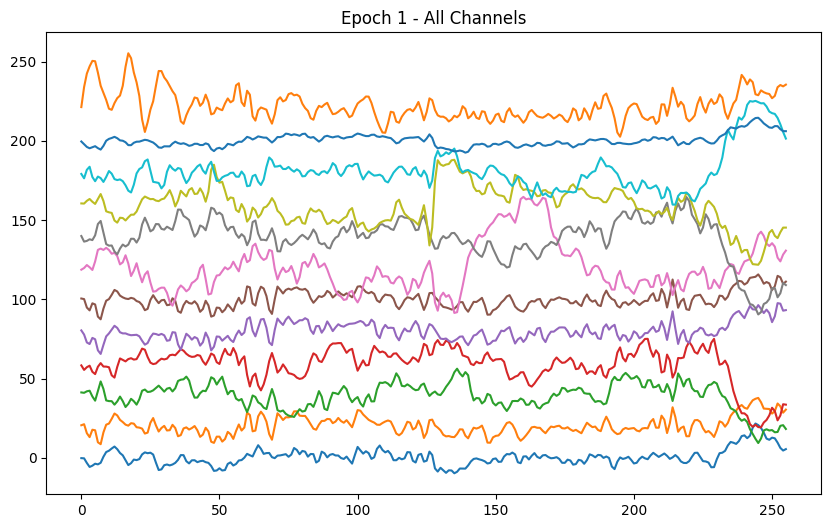

In [20]:
epochs = data[:num_epochs * epoch_length].reshape(num_epochs, epoch_length, num_channels)

print("Epochs shape:", epochs.shape)
print(epochs.shape)

plt.figure(figsize=(10,6))

for i in range(12):
    plt.plot(epochs[0,:,i] + i*20)

plt.title("Epoch 1 - All Channels")
plt.show()


Rejected epochs: [9, 10, 13, 14, 16, 18, 20, 21, 25, 26, 41, 42, 45, 46, 47, 48, 50, 51, 52, 54, 56, 61, 69, 71, 72, 73, 74, 75, 76, 77, 78, 80, 84, 85, 96, 97, 104, 105, 122, 145, 146, 148, 149, 153, 154, 161, 199, 200, 209, 210, 226, 227, 228, 229, 255, 256, 262, 267, 287, 288, 297, 299, 301, 304, 308, 311, 330, 370, 454, 455, 461, 490, 572, 646, 719, 720, 721, 917, 947, 1181, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204]


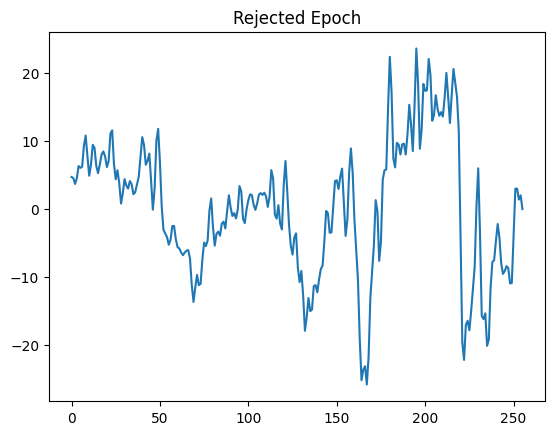

In [27]:
print("Rejected epochs:", bad_epochs)

plt.plot(epochs[bad_epochs[0],:,0]) 
plt.title("Rejected Epoch")
plt.show()

Original epochs: (1206, 256, 12)
Clean epochs: (1116, 256, 12)


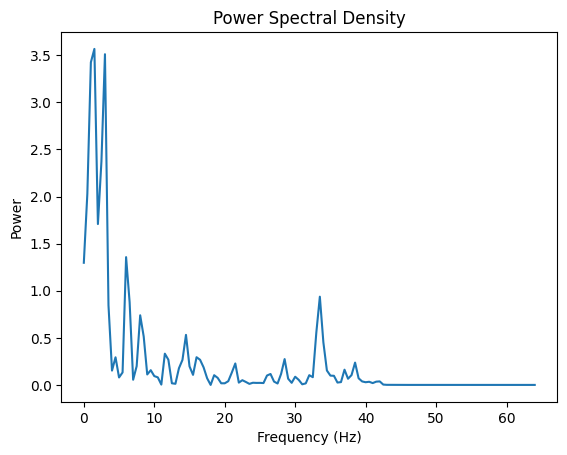

In [26]:
threshold = 100

good_epochs = []

for i in range(epochs.shape[0]):
    
    epoch = epochs[i]
    
    if np.max(np.abs(epoch)) < threshold:
        good_epochs.append(epoch)

good_epochs = np.array(good_epochs)

print("Original epochs:", epochs.shape)
print("Clean epochs:", good_epochs.shape)

bad_epochs = []

for i in range(epochs.shape[0]):
    
    if np.max(np.abs(epochs[i])) > threshold:
        bad_epochs.append(i)

from scipy.signal import welch

fs = 128

epoch = good_epochs[0,:,0]   # epoch 1, channel 1

f, psd = welch(epoch, fs=fs)

plt.plot(f, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density")
plt.show()

In [28]:
import numpy as np
from scipy.signal import welch

fs = 128

def bandpower(psd, freqs, fmin, fmax):

    idx = (freqs >= fmin) & (freqs <= fmax)

    return simpson(psd[idx], freqs[idx])

features = []

for ep in range(good_epochs.shape[0]):

    epoch_features = []

    for ch in range(good_epochs.shape[2]):

        signal = good_epochs[ep,:,ch]

        f, psd = welch(signal, fs=fs)

        delta = bandpower(psd, f, 0.5, 4)
        theta = bandpower(psd, f, 4, 8)
        alpha = bandpower(psd, f, 8, 13)
        beta  = bandpower(psd, f, 13, 30)

        epoch_features.extend([delta, theta, alpha, beta])

    features.append(epoch_features)

features = np.array(features)

print("Feature matrix shape:", features.shape)



Feature matrix shape: (1116, 48)


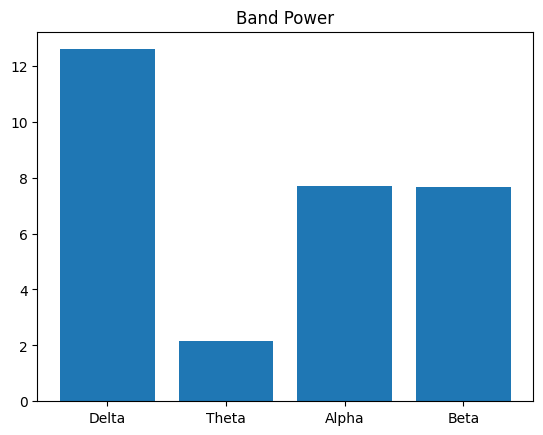

In [29]:

total_power = delta + theta + alpha + beta

delta_rel = delta / total_power
theta_rel = theta / total_power
alpha_rel = alpha / total_power
beta_rel  = beta / total_power
epoch_features.extend([
delta, theta, alpha, beta,
delta_rel, theta_rel, alpha_rel, beta_rel
])
beta_alpha_ratio = beta / alpha
theta_beta_ratio = theta / beta
epoch_features.extend([
beta_alpha_ratio,
theta_beta_ratio
])
bands = ['Delta','Theta','Alpha','Beta']
powers = [delta, theta, alpha, beta]

plt.bar(bands, powers)
plt.title("Band Power")
plt.show()


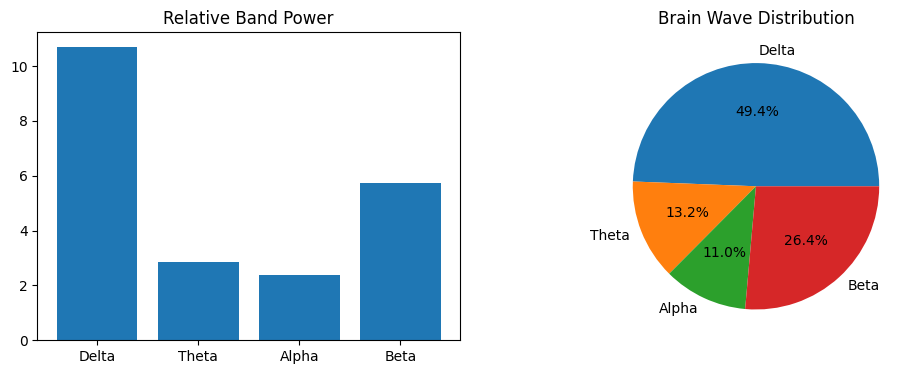

    Band  Absolute Power  Relative Power
0  Delta        9.364386       10.694653
1  Theta        1.183488        2.853552
2  Alpha        0.979507        2.391036
3   Beta        1.880765        5.718186


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------- Take average of all epochs (recommended) --------
avg_features = np.mean(features, axis=0)

# -------- Since 12 channels, take first channel for demo --------
# Each channel has 14 features
ch0 = avg_features[:14]

delta, theta, alpha, beta = ch0[0], ch0[1], ch0[2], ch0[3]
delta_rel, theta_rel, alpha_rel, beta_rel = ch0[4], ch0[5], ch0[6], ch0[7]

# -------- Bar Chart --------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(['Delta','Theta','Alpha','Beta'],
        [delta_rel, theta_rel, alpha_rel, beta_rel])
plt.title("Relative Band Power")

# -------- Pie Chart --------
plt.subplot(1,2,2)
plt.pie([delta_rel, theta_rel, alpha_rel, beta_rel],
        labels=['Delta','Theta','Alpha','Beta'],
        autopct='%1.1f%%')
plt.title("Brain Wave Distribution")

plt.show()

# -------- Table --------
df = pd.DataFrame({
    "Band": ["Delta","Theta","Alpha","Beta"],
    "Absolute Power": [delta, theta, alpha, beta],
    "Relative Power": [delta_rel, theta_rel, alpha_rel, beta_rel]
})

print(df)


In [31]:
print("\n--- Interpretation ---")

if beta_rel > alpha_rel:
    print("Person is in FOCUSED / ACTIVE state")
elif alpha_rel > beta_rel:
    print("Person is RELAXED")
elif theta_rel > beta_rel:
    print("Person may be DROWSY")
else:
    print("Mixed mental state detected")


--- Interpretation ---
Person is in FOCUSED / ACTIVE state


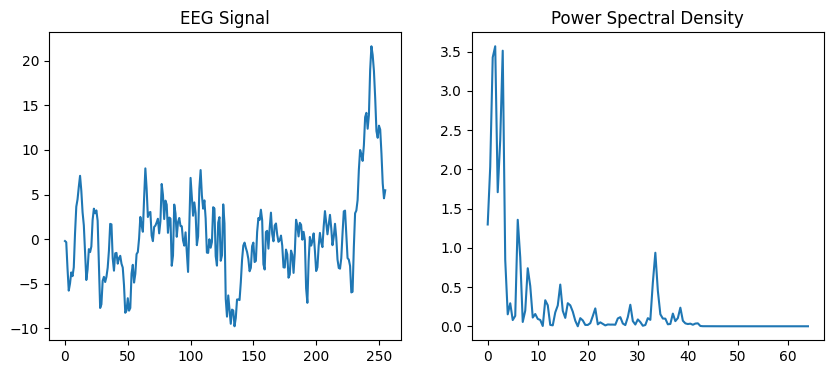

In [32]:
from scipy.signal import welch

signal = good_epochs[0,:,0]

f, psd = welch(signal, fs=128)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(signal)
plt.title("EEG Signal")

plt.subplot(1,2,2)
plt.plot(f, psd)
plt.title("Power Spectral Density")

plt.show()


In [34]:
labels = []

for i in range(features.shape[0]):
    
    # take first channel features (or average)
    ch0 = features[i][:14]
    
    delta_rel = ch0[4]
    theta_rel = ch0[5]
    alpha_rel = ch0[6]
    beta_rel  = ch0[7]
    
    # -------- Rule-based labeling --------
    if beta_rel > 0.35:
        labels.append(2)   # Focused
    
    elif alpha_rel > 0.35:
        labels.append(1)   # Relaxed
    
    else:
        labels.append(0)   # Drowsy

# convert to numpy
y = np.array(labels)

print("Labels shape:", y.shape)

Labels shape: (1116,)


In [35]:
print("Max amplitude:", np.max(epochs))
print("Min amplitude:", np.min(epochs))
print("Absolute max:", np.max(np.abs(epochs)))

Max amplitude: 2032.6925380160358
Min amplitude: -2587.2824937718765
Absolute max: 2587.2824937718765
